# Updates

In [14]:
import sars
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

file = "data/herpetofauna.csv"

In [15]:
raw = pd.read_csv(file)
raw.describe()

,Area,TotalHerpetofauna,Amphibians,Reptiles
count,4.000000,4.000000,4.000000,4.000000
mean,10674.575000,70.250000,42.750000,27.500000
std,17927.385846,30.630867,20.254629,11.090537
min,9.300000,41.000000,20.000000,21.000000
25%,837.825000,54.500000,33.500000,21.000000
50%,2625.500000,63.500000,41.000000,22.500000
75%,12462.250000,79.250000,50.250000,29.000000
max,37438.000000,113.000000,69.000000,44.000000


In [16]:
data_herpetofauna = sars.from_csv(file, area_col="Area", species_col="TotalHerpetofauna")
data_amphibians = sars.from_csv(file, area_col="Area", species_col="Amphibians")
data_reptiles = sars.from_csv(file, area_col="Area", species_col="Reptiles")

data_amphibians.head()

,area,species
0,9.3,20
1,1114.0,38
2,4137.0,44
3,37438.0,69


## Herpetofauna Power-Law SAR (S = cA^z)

Herpetofauna SARFit(model='power', c=22.4900  z=0.1478, R²=0.9162, AICc=inf)

Parameters: {'c': np.float64(22.490047797364802), 'z': np.float64(0.14783704201930972)}
R²: 0.9162
AICc: inf



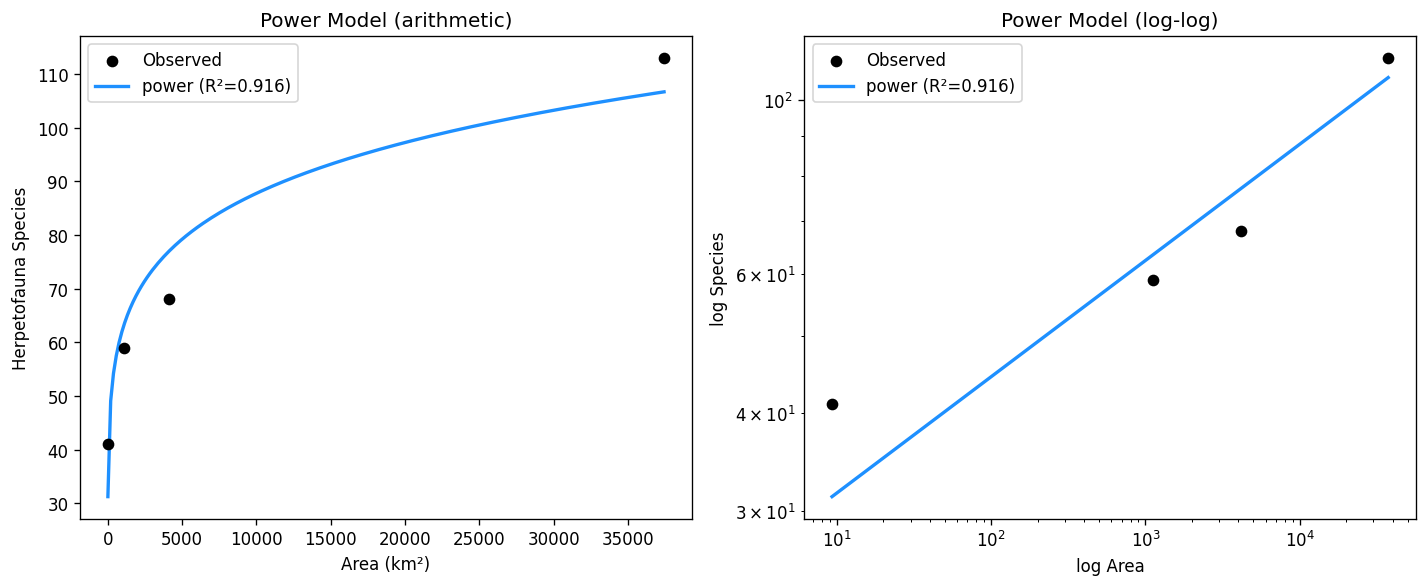

In [17]:
herp_power = sars.sar_power(data_herpetofauna)

print(f"Herpetofauna {herp_power}")
print(f"\nParameters: {herp_power.params}")
print(f"R²: {herp_power.r_squared:.4f}")
print(f"AICc: {herp_power.aicc:.2f}\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sars.plot_fit(herp_power, log=False, ax=axes[0])
axes[0].set_title("Power Model (arithmetic)")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Herpetofauna Species")

sars.plot_fit(herp_power, log=True, ax=axes[1])
axes[1].set_title("Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")

plt.tight_layout()
plt.show()

The herpetofauna power model yields c = 22.49 and z = 0.148, with R² = 0.92. The z-value falls within the canonical mainland/nested range of 0.10–0.20, consistent with the nested sampling design. This is a moderately strong fit, suggesting total herpetofauna richness scales predictably with area across these spatial scales.

## Amphibian Power-Law SAR (S = cA^z)

Amphibian SARFit(model='power', c=12.2827  z=0.1616, R²=0.9849, AICc=inf)

Parameters: {'c': np.float64(12.282728396934932), 'z': np.float64(0.16155892187835752)}
R²: 0.9849
AICc: inf



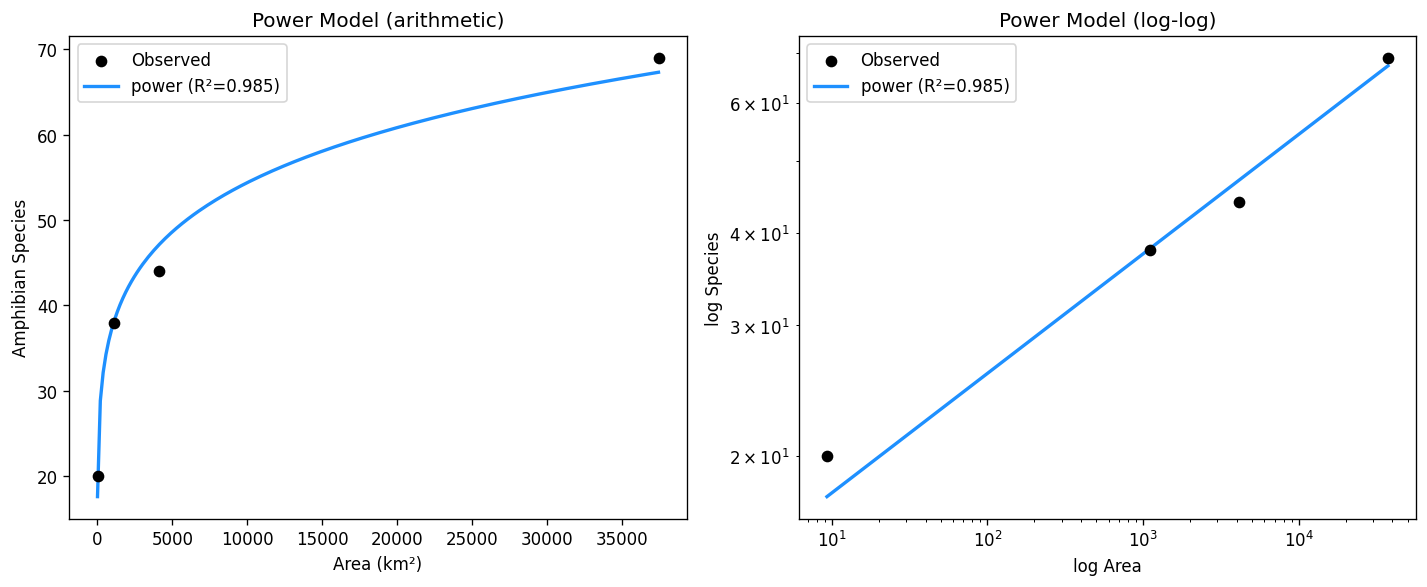

In [18]:
amp_power = sars.sar_power(data_amphibians)

print(f"Amphibian {amp_power}")
print(f"\nParameters: {amp_power.params}")
print(f"R²: {amp_power.r_squared:.4f}")
print(f"AICc: {amp_power.aicc:.2f}\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sars.plot_fit(amp_power, log=False, ax=axes[0])
axes[0].set_title("Power Model (arithmetic)")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Amphibian Species")

sars.plot_fit(amp_power, log=True, ax=axes[1])
axes[1].set_title("Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")

plt.tight_layout()
plt.show()

Amphibians show an excellent power-law fit (R² = 0.98), with c = 12.28 and z = 0.162. The higher z relative to herpetofauna indicates a steeper species-area scaling — amphibian richness increases more rapidly with area than the combined group. This is consistent with the original publication's finding that amphibians drive the overall herpetofauna SAR pattern.

## Reptile Power-Law SAR (S = cA^z)

Reptile SARFit(model='power', c=10.9570  z=0.1205, R²=0.6619, AICc=inf)

Parameters: {'c': np.float64(10.957036762348634), 'z': np.float64(0.12050487220772282)}
R²: 0.6619
AICc: inf



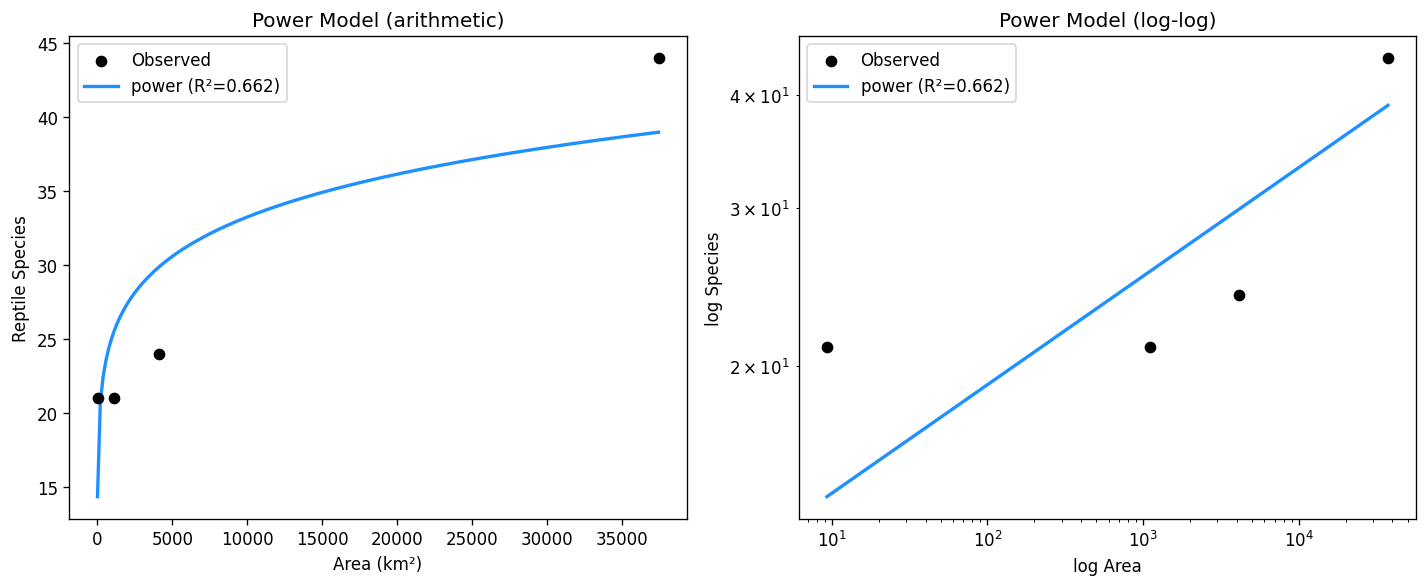

In [19]:
rep_power = sars.sar_power(data_reptiles)

print(f"Reptile {rep_power}")
print(f"\nParameters: {rep_power.params}")
print(f"R²: {rep_power.r_squared:.4f}")
print(f"AICc: {rep_power.aicc:.2f}\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sars.plot_fit(rep_power, log=False, ax=axes[0])
axes[0].set_title("Power Model (arithmetic)")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Reptile Species")

sars.plot_fit(rep_power, log=True, ax=axes[1])
axes[1].set_title("Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")

plt.tight_layout()
plt.show()

The reptile power model is notably weaker (R² = 0.66), with c = 10.96 and z = 0.121. The low R² reflects the unusual data structure: reptile richness is flat from Steele Creek Park (9.3 km², 21 spp.) to Sullivan County (1,114 km², 21 spp.), then jumps at larger scales. This plateau-and-jump pattern is fundamentally non-power-law, and the power model produces large residuals at every data point.

## Amphibians vs. Reptiles — Power Model Comparison

In [20]:
print("Amphibians:", amp_power.params, f"  R²={amp_power.r_squared:.4f}")
print("Reptiles:  ", rep_power.params, f"  R²={rep_power.r_squared:.4f}")

Amphibians: {'c': np.float64(12.282728396934932), 'z': np.float64(0.16155892187835752)}   R²=0.9849
Reptiles:   {'c': np.float64(10.957036762348634), 'z': np.float64(0.12050487220772282)}   R²=0.6619


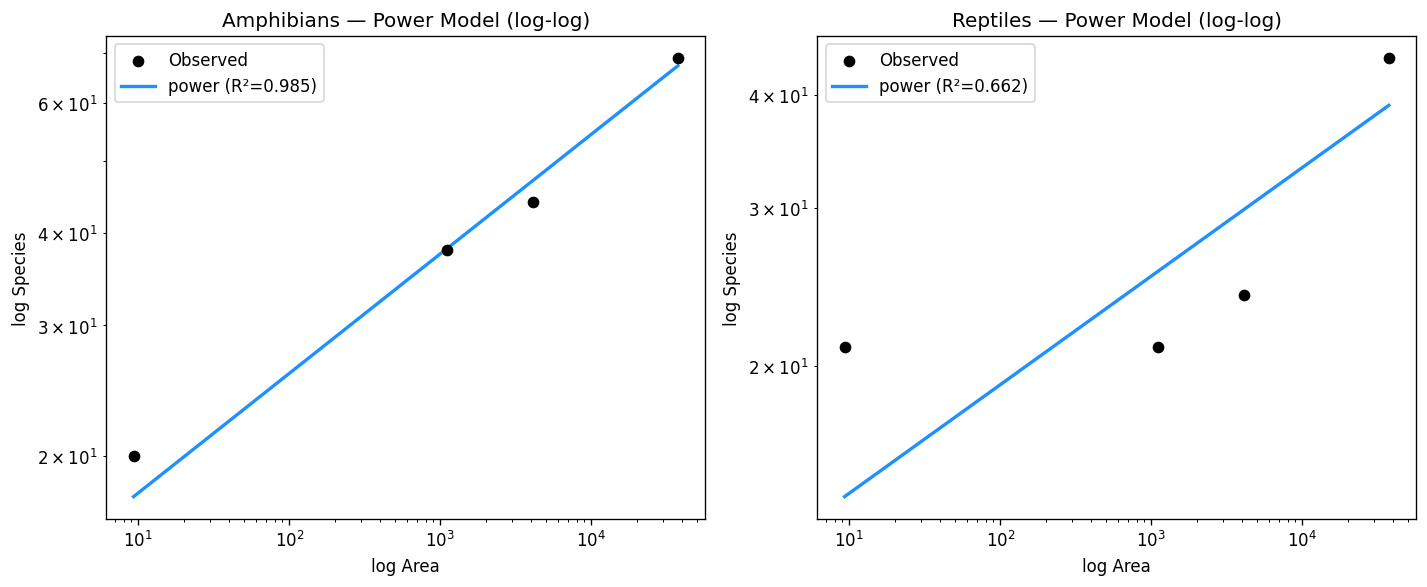

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sars.plot_fit(amp_power, log=True, ax=axes[0])
axes[0].set_title("Amphibians — Power Model (log-log)")
axes[0].set_xlabel("log Area")
axes[0].set_ylabel("log Species")

sars.plot_fit(rep_power, log=True, ax=axes[1])
axes[1].set_title("Reptiles — Power Model (log-log)")
axes[1].set_xlabel("log Area")
axes[1].set_ylabel("log Species")

plt.tight_layout()
plt.show()

The contrast is stark: amphibians exhibit a strong power-law SAR (R² = 0.98) while reptiles do not (R² = 0.66). Both z-values fall within the expected mainland/nested range (0.10–0.20), but the amphibian z (0.162) is notably higher than reptile z (0.121), indicating a stronger area-richness scaling. The reptile relationship appears driven primarily by the jump at the largest spatial scale (Eastern Tennessee) rather than a consistent scaling pattern.

## Residual Diagnostics

Residual plots reveal the pattern of model misfit. For the reptile power model, the residual pattern (positive–negative–negative–positive) confirms the systematic misfit to the plateau-and-jump data structure.

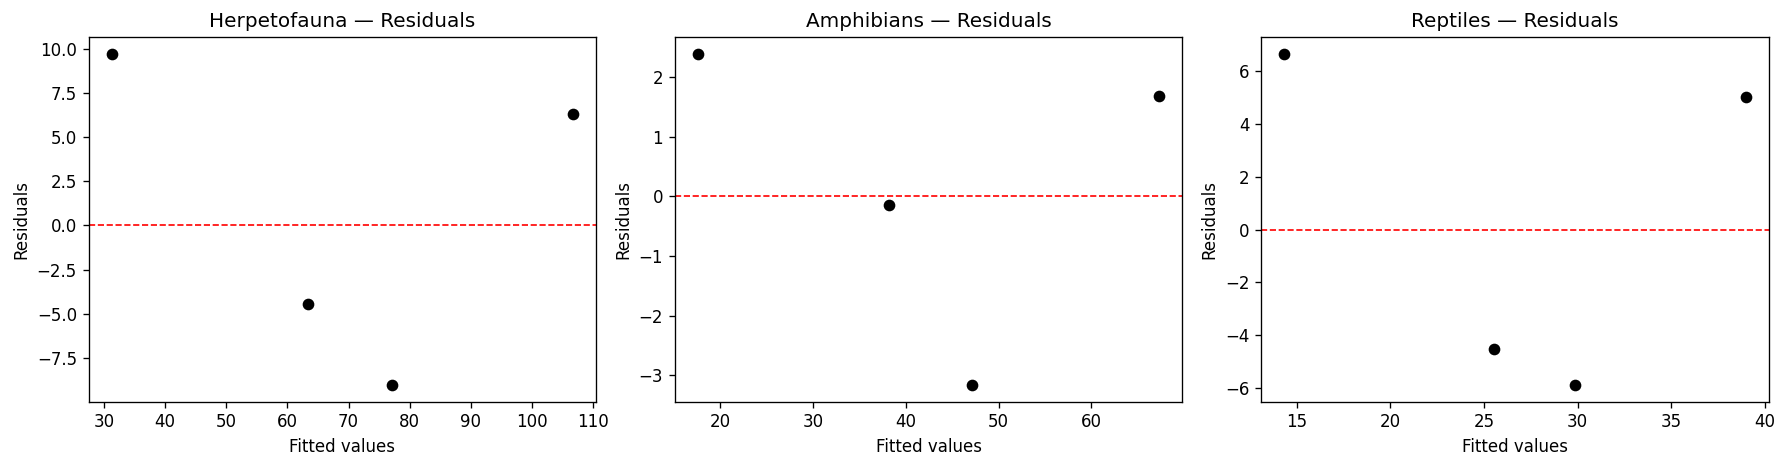

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sars.plot_residuals(herp_power, ax=axes[0])
axes[0].set_title("Herpetofauna — Residuals")

sars.plot_residuals(amp_power, ax=axes[1])
axes[1].set_title("Amphibians — Residuals")

sars.plot_residuals(rep_power, ax=axes[2])
axes[2].set_title("Reptiles — Residuals")

plt.tight_layout()
plt.show()

# Herpetofauna Multi-Model Comparison

Fit all supported SAR models and rank by AICs.

In [23]:
multi = sars.sar_multi(data_herpetofauna)
print(multi)
multi.summary

/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/sars/_models.py:324: RuntimeWarning: overflow encountered in power
  return c * a ** (z1 * a**z2)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/least_squares.py:965: RuntimeWarning: overflow encountered in dot
  initial_cost = 0.5 * np.dot(f0, f0)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf.py:224: RuntimeWarning: overflow encountered in dot
  cost = 0.5 * np.dot(f, f)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:595: RuntimeWarning: overflow encountered in dot
  return J.T.dot(f)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf.py:353: RuntimeWarning: overflow encountered in dot
  cost_new = 0.5 * np.dot(f_new, f_new)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnor

MultiSARFit(20 models, best='power')


,model,R2,AIC,AICc,BIC,delta_AICc,weight,shape,asymptote
0,power,0.916192,33.659954,inf,31.818837,NaN,0.0,convex,NaN
1,powerR,0.997662,21.343804,inf,18.888981,NaN,0.0,convex,NaN
2,epm1,0.996579,22.865139,inf,20.410316,NaN,0.0,convex,NaN
3,epm2,0.998484,19.609055,inf,17.154232,NaN,0.0,convex,NaN
4,p1,0.916192,35.659954,inf,33.205131,NaN,0.0,convex,NaN
5,p2,0.916192,35.659954,inf,33.205131,NaN,0.0,convex,NaN
6,loga,0.792958,37.277513,inf,35.436396,NaN,0.0,convex,NaN
7,koba,0.793606,37.264979,inf,35.423862,NaN,0.0,convex,NaN
8,mmf,0.916185,35.660290,inf,33.205467,NaN,0.0,sigmoid,999999.999998
9,monod,0.415964,41.425675,inf,39.584559,NaN,0.0,convex,80.479797


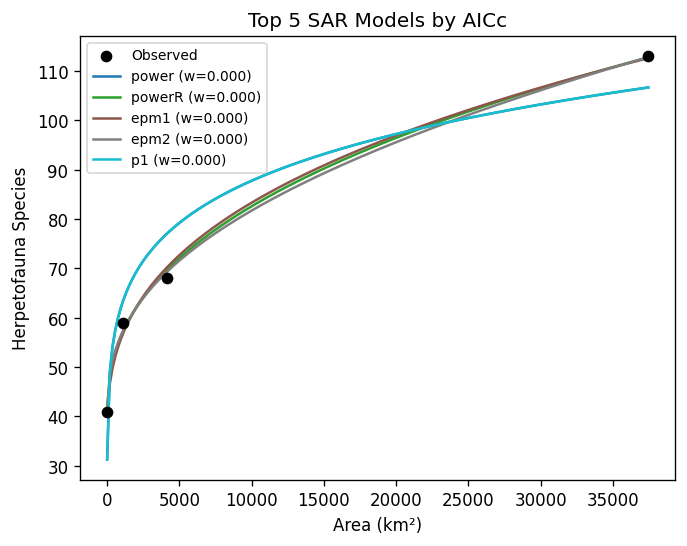

In [24]:
sars.plot_multi(multi, top_n=5)
plt.title("Top 5 SAR Models by AICc")
plt.xlabel("Area (km²)")
plt.ylabel("Herpetofauna Species")
plt.show()

### Note: AICc Limitation

With n = 4 observations and k ≥ 3 estimated parameters (all models include σ), AICc = AIC + 2k(k+1)/(n−k−1) yields AICc = ∞ because the denominator n−k−1 ≤ 0. This means Akaike weights are all zero and model averaging via `sars.sar_average()` cannot produce meaningful results for this dataset. AIC and BIC remain finite and can be used cautiously for ranking, but all model comparisons should be interpreted with caution given the severe overfitting risk at this sample size.

# Multi-Model Comparison Amphibians vs. Reptiles

/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/sars/_models.py:324: RuntimeWarning: overflow encountered in power
  return c * a ** (z1 * a**z2)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/least_squares.py:965: RuntimeWarning: overflow encountered in dot
  initial_cost = 0.5 * np.dot(f0, f0)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf.py:224: RuntimeWarning: overflow encountered in dot
  cost = 0.5 * np.dot(f, f)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/common.py:595: RuntimeWarning: overflow encountered in dot
  return J.T.dot(f)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/scipy/optimize/_lsq/trf.py:353: RuntimeWarning: overflow encountered in dot
  cost_new = 0.5 * np.dot(f_new, f_new)
/home/john/repos/scp-sar-ar/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnor

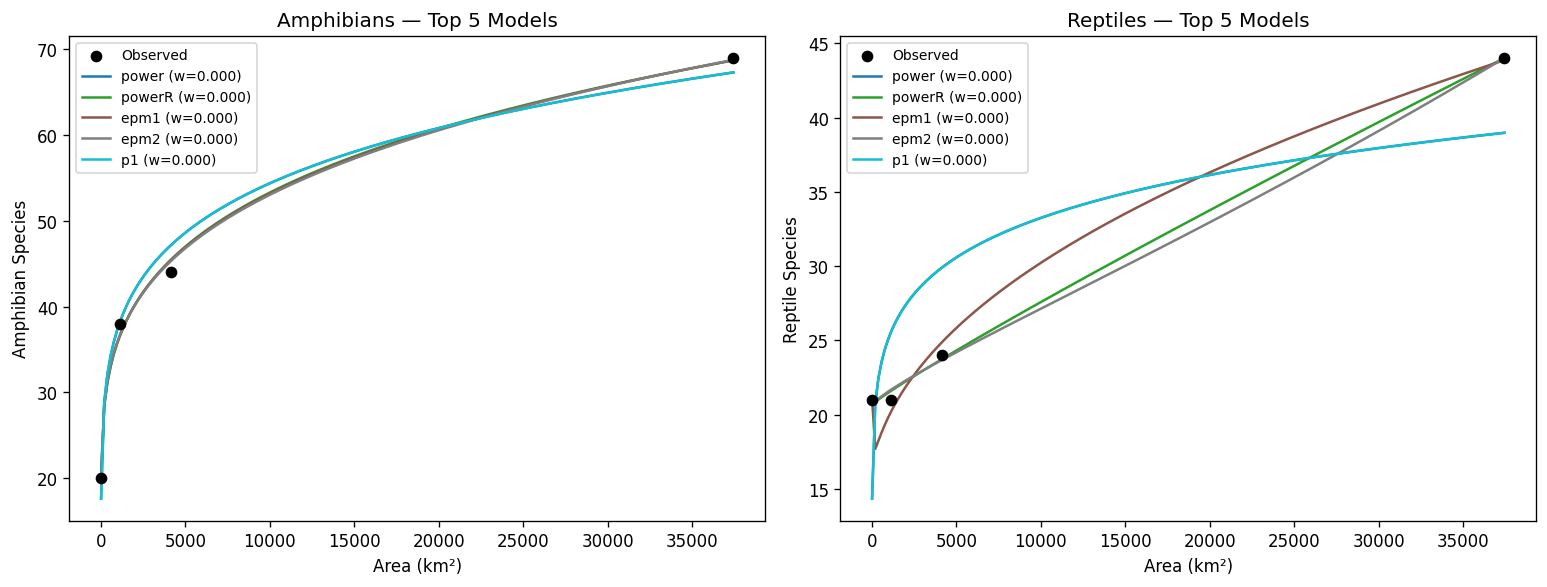

In [25]:
amp_multi = sars.sar_multi(data_amphibians)
rep_multi = sars.sar_multi(data_reptiles)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sars.plot_multi(amp_multi, top_n=5, ax=axes[0])
axes[0].set_title("Amphibians — Top 5 Models")
axes[0].set_xlabel("Area (km²)")
axes[0].set_ylabel("Amphibian Species")

sars.plot_multi(rep_multi, top_n=5, ax=axes[1])
axes[1].set_title("Reptiles — Top 5 Models")
axes[1].set_xlabel("Area (km²)")
axes[1].set_ylabel("Reptile Species")

plt.tight_layout()
plt.show()

In [26]:
print("=== Amphibians — Top 5 ===")
display(amp_multi.summary.head())
print("\n=== Reptiles — Top 5 ===")
display(rep_multi.summary.head())

=== Amphibians — Top 5 ===


,model,R2,AIC,AICc,BIC,delta_AICc,weight,shape,asymptote
0,power,0.984921,23.489935,inf,21.648818,NaN,0.0,convex,NaN
1,powerR,0.996382,19.780544,inf,17.325722,NaN,0.0,convex,NaN
2,epm1,0.996664,19.456175,inf,17.001352,NaN,0.0,convex,NaN
3,epm2,0.996965,19.077501,inf,16.622679,NaN,0.0,convex,NaN
4,p1,0.984921,25.489935,inf,23.035112,NaN,0.0,convex,NaN



=== Reptiles — Top 5 ===


,model,R2,AIC,AICc,BIC,delta_AICc,weight,shape,asymptote
0,power,0.661880,31.112099,inf,29.270982,NaN,0.0,convex,NaN
1,powerR,0.998608,11.142668,inf,8.687846,NaN,0.0,convex,NaN
2,epm1,0.995972,15.391081,inf,12.936259,NaN,0.0,convex,NaN
3,epm2,0.998221,12.121918,inf,9.667095,NaN,0.0,convex,NaN
4,p1,0.661880,33.112099,inf,30.657276,NaN,0.0,convex,NaN


## Threshold / Breakpoint Analysis

`sars.sar_threshold()` tests for the small-island effect by fitting piecewise models with breakpoints. Three candidate models are compared: continuous two-slope (ContOne), left-horizontal + right slope (ZslopeOne), and linear (no breakpoint).

In [27]:
herp_thresh = sars.sar_threshold(data_herpetofauna)
amp_thresh = sars.sar_threshold(data_amphibians)
rep_thresh = sars.sar_threshold(data_reptiles)

print("=== Herpetofauna ===")
print(herp_thresh)
print("\n=== Amphibians ===")
print(amp_thresh)
print("\n=== Reptiles ===")
print(rep_thresh)

=== Herpetofauna ===
ThresholdFit(best='Linear')

=== Amphibians ===
ThresholdFit(best='Linear')

=== Reptiles ===
ThresholdFit(best='Linear')


For all three taxonomic groups, the threshold analysis selects **Linear** as the best model — no breakpoint is detected. This is expected given n = 4, as there are insufficient data points to reliably estimate a breakpoint location. The result confirms that no small-island effect is statistically supported at this sample size, though additional intermediate spatial scales would be needed to test this more rigorously.